In [3]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
print(os.getcwd())

C:\Users\Pavan kumar\CodeAlpha_Sales Prediction


In [7]:
#Load dataset ..
df = pd.read_csv("sales_Data.csv")
print("Data Loaded Successfully\n")
print(df.head())

Data Loaded Successfully

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [9]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [10]:
df.dropna(inplace=True)

In [11]:
df.columns = df.columns.str.strip()

In [12]:
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)

In [13]:
#Feature Engineering
#converting categorical features
df = pd.get_dummies(df, drop_first=True)

In [14]:
#seperating features and target 
X = df.drop("Sales", axis=1)
y = df["Sales"]


In [ ]:
# Train & Test Data Split

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
#model training(Regression model)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Performance:
MAE : 1.4650601050102938
RMSE: 1.788576100865967
R2 Score: 0.898648915141708


In [ ]:
#advertising impact analysis(correlation heatmap)

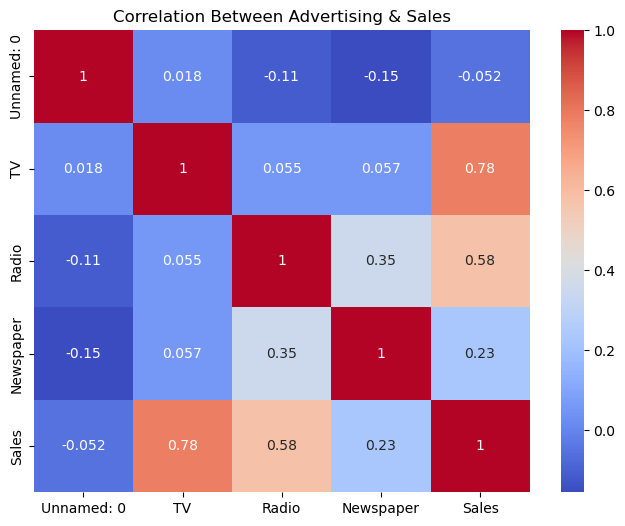

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Advertising & Sales")
plt.show()

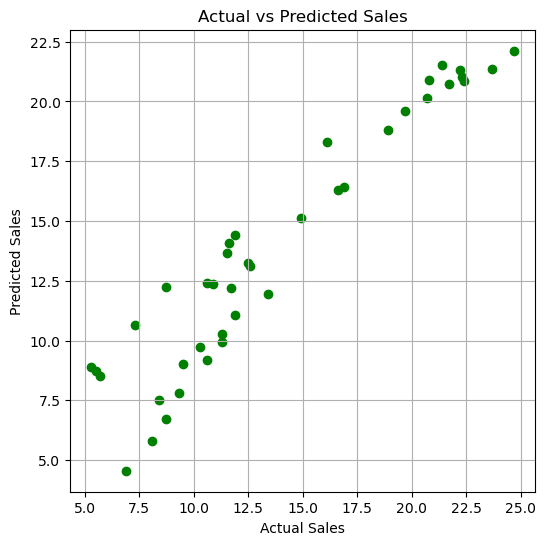

In [20]:
# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color="green")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.grid()
plt.show()


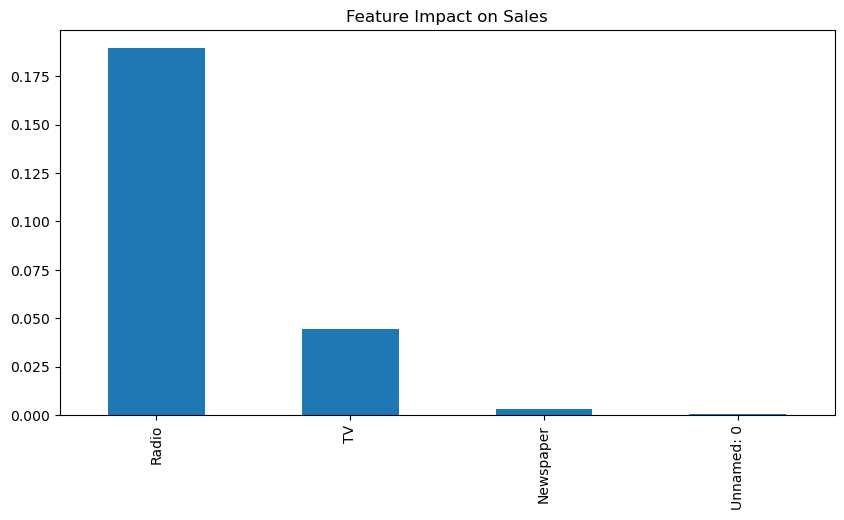

In [21]:
#last step(feature importance)

importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values(ascending=False).plot(
    kind='bar', figsize=(10,5), title="Feature Impact on Sales"
)
plt.show()